In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv("sales_data.csv")

# data prepared for the plots
product_sales = df.groupby("Product")["Sales"].sum()
region_sales = df.groupby("Region")["Sales"].sum()

print("Total sales of each product:")
print(product_sales)
print("\nTotal sales of each region:")
print(region_sales)

Total sales of each product:
Product
Laptop     511000
Mobile     395000
Printer    295000
Name: Sales, dtype: int64

Total sales of each region:
Region
East     286000
North    341000
South    303000
West     271000
Name: Sales, dtype: int64


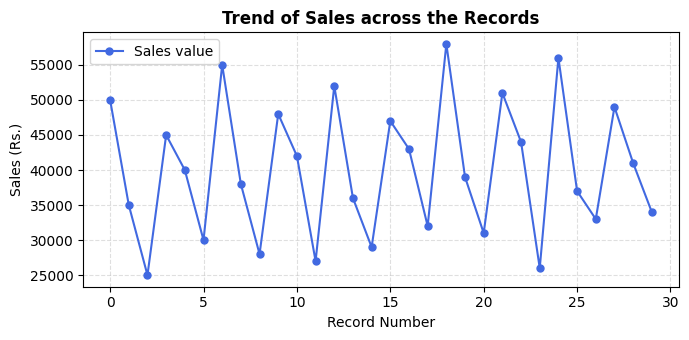

In [2]:
# ---------------- Line plot ----------------
plt.figure(figsize=(7, 3.5))
plt.plot(df.index, df["Sales"], marker="o", linestyle="-",
         color="royalblue", linewidth=1.5, markersize=5,
         label="Sales value")

plt.title("Trend of Sales across the Records", fontsize=12, fontweight="bold")
plt.xlabel("Record Number")
plt.ylabel("Sales (Rs.)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

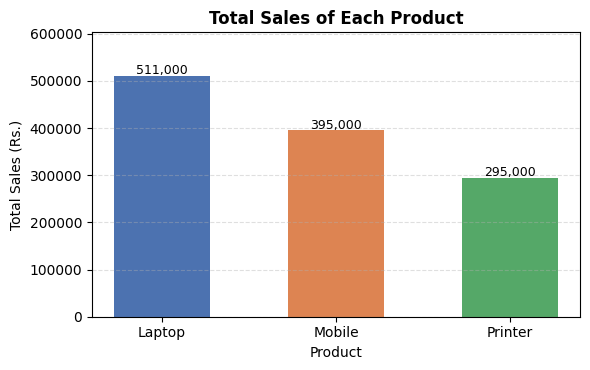

In [3]:
# ---------------- Bar chart ----------------
plt.figure(figsize=(6, 3.8))
bars = plt.bar(product_sales.index, product_sales.values,
               color=["#4c72b0", "#dd8452", "#55a868"], width=0.55)

# the value is written on top of each bar
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 4000,
             f"{int(b.get_height()):,}", ha="center", fontsize=9)

plt.title("Total Sales of Each Product", fontsize=12, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Total Sales (Rs.)")
plt.ylim(0, product_sales.max() * 1.18)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

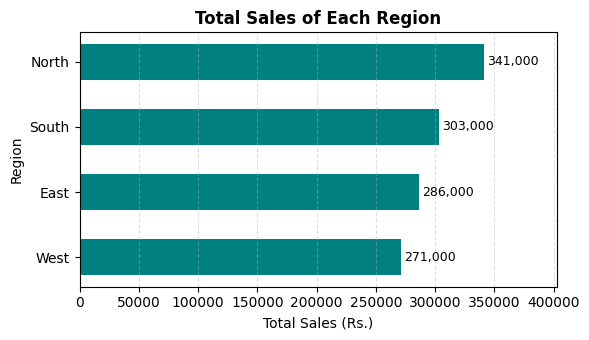

In [4]:
# ---------------- Horizontal bar chart ----------------
ordered = region_sales.sort_values()

plt.figure(figsize=(6, 3.5))
plt.barh(ordered.index, ordered.values, color="teal", height=0.55)

for i, v in enumerate(ordered.values):
    plt.text(v + 3000, i, f"{int(v):,}", va="center", fontsize=9)

plt.title("Total Sales of Each Region", fontsize=12, fontweight="bold")
plt.xlabel("Total Sales (Rs.)")
plt.ylabel("Region")
plt.xlim(0, ordered.max() * 1.18)
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

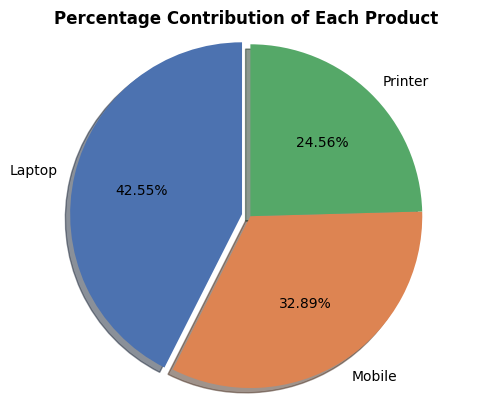

In [5]:
# ---------------- Pie chart ----------------
plt.figure(figsize=(5, 4.2))
plt.pie(product_sales.values,
        labels=product_sales.index,
        autopct="%1.2f%%",
        startangle=90,
        colors=["#4c72b0", "#dd8452", "#55a868"],
        explode=(0.05, 0, 0),
        shadow=True,
        textprops={"fontsize": 10})

plt.title("Percentage Contribution of Each Product", fontsize=12, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

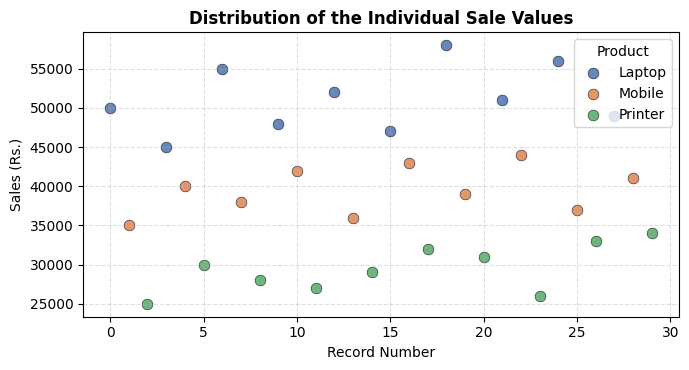

In [6]:
# ---------------- Scatter plot ----------------
colors = {"Laptop": "#4c72b0", "Mobile": "#dd8452", "Printer": "#55a868"}

plt.figure(figsize=(7, 3.8))
for product in df["Product"].unique():
    sub = df[df["Product"] == product]
    plt.scatter(sub.index, sub["Sales"], s=60, alpha=0.85,
                color=colors[product], label=product, edgecolors="black",
                linewidths=0.4)

plt.title("Distribution of the Individual Sale Values", fontsize=12, fontweight="bold")
plt.xlabel("Record Number")
plt.ylabel("Sales (Rs.)")
plt.legend(title="Product")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

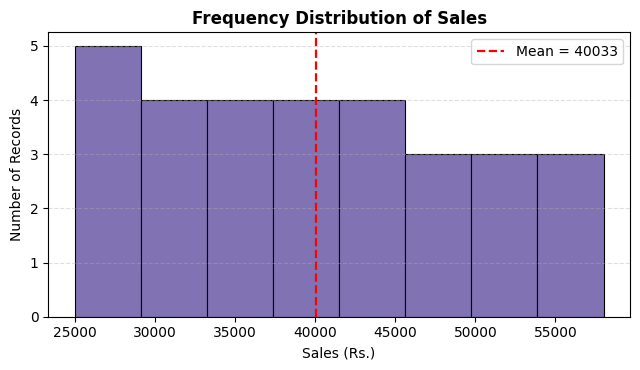

In [7]:
# ---------------- Histogram ----------------
plt.figure(figsize=(6.5, 3.8))
plt.hist(df["Sales"], bins=8, color="#8172b3",
         edgecolor="black", linewidth=0.8)

plt.axvline(df["Sales"].mean(), color="red", linestyle="--",
            linewidth=1.6, label=f"Mean = {df['Sales'].mean():.0f}")

plt.title("Frequency Distribution of Sales", fontsize=12, fontweight="bold")
plt.xlabel("Sales (Rs.)")
plt.ylabel("Number of Records")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()